In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report


In [6]:
df= pd.read_csv('data.csv')
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [59]:
def preprocess_data(df):

    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")
        else:
            df[col] = df[col].fillna(df[col].median())


    numeric_cols = df.select_dtypes(include=[np.number]).columns
    is_outlier = pd.Series(False, index=df.index)

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        

        is_outlier |= (df[col] < lower_bound) | (df[col] > upper_bound)


    df_clean = df[~is_outlier]
    
    return df_clean


df_clean = preprocess_data(df)
print("Data Cleaned. New Shape:", df_clean.shape)

Data Cleaned. New Shape: (3, 96)


In [60]:
def feature_engineering(df):

    date_cols = [col for col in df.columns if 'date' in col.lower()]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col])
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_day_of_week'] = df[col].dt.dayofweek
    

    le = LabelEncoder()
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))
        
    
    return df

df_engineered = feature_engineering(df_clean)

Actionable Insight: Model RMSE is 0.02


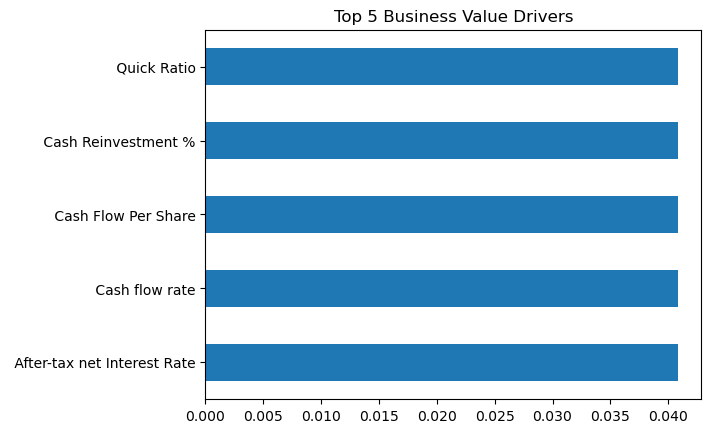

In [61]:

target_col = df_engineered.columns[-1]
X = df_engineered.drop(columns=[target_col])
y = df_engineered[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=100) # Use Classifier if y is categorical
model.fit(X_train, y_train)


predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"Actionable Insight: Model RMSE is {rmse:.2f}")


importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.title("Top 5 Business Value Drivers")
plt.show()